# Joint SSMT — Single-Trial Quickstart

This notebook walks through the **single-trial** spike-field coupling pipeline:

1. **Simulate** synthetic LFP + spike data with known coupling
2. **Run inference** using the Joint SSMT model
3. **Interpret the core results** — coupling detection heatmaps and spectrogram
4. Additional diagnostic and comparison plots


In [1]:
# If you haven't installed the package yet, uncomment and run:
# !pip install -e ..

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from joint_ssmt import (
    simulate_single_trial,
    SingleTrialSimConfig,
)
from joint_ssmt.io import run_inference, load_results

/home/bowen27/miniconda3/envs/jax312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 1. Simulate Data

We generate synthetic data with **known** spike-field coupling so we can verify the inference.

The simulation creates:
- An LFP signal containing oscillatory components at several frequencies (11, 19, 27, 43 Hz plus two "signal-only" bands at 7 and 35 Hz that appear in the LFP but do **not** drive spiking)
- Spike trains for 3 units, each coupled to 2 of the 4 couplable bands

> **For real data** you would skip this step and load your own `lfp` (1-D array, shape `(T,)`) and `spikes` (2-D array, shape `(S, T_fine)`).

In [3]:
cfg = SingleTrialSimConfig(
    duration_sec=60.0,  # 60 s (use >=60 s for real analyses)
    S=3,                # 3 spike units
    k_active=2,         # each unit couples to 2 of 4 couplable bands
    b0_mu=-3.0,         # baseline log-odds (controls mean firing rate)
)

sim = simulate_single_trial(cfg, seed=42)

lfp    = sim['LFP']        # (T,)
spikes = sim['spikes']     # (S, T_fine)

print(f"LFP shape:    {lfp.shape}   (T = {lfp.shape[0]} samples at {cfg.fs} Hz)")
print(f"Spikes shape: {spikes.shape} (S = {spikes.shape[0]} units)")
print(f"\nGround-truth coupled frequencies: {sim['freqs_hz_coupled']}")
print(f"Signal-only (uncoupled) frequencies: {sim['freqs_hz_extra']}")
print(f"\nCoupling mask (rows=units, cols=signal bands):")
print(sim['masks'])

Single-trial simulation setup:
  Units: S=3
  Coupled signal bands (Jc=4): [11. 19. 27. 43.]
  Extra uncoupled signal bands (Ju=2): [ 7. 35.]
  Total signal bands (J=6): [11. 19. 27. 43.  7. 35.]
  LFP: T=60000 samples at fs=1000.0 Hz
  Spikes: T_fine=60000 samples at 1000.0 Hz
Generating OU latent processes...
Computing derotated latents for spike predictors...
Generating coupling parameters...
  beta_true shape: (3, 13) (SEPARATED layout)
Generating spikes...
  Spikes per unit: [1334 2283 2205]
  Mean firing rate: 32.34 Hz
  Unit 0 firing rate: 22.23 Hz
  Unit 1 firing rate: 38.05 Hz
  Unit 2 firing rate: 36.75 Hz
Generating LFP with broadband noise...
Simulation complete.
LFP shape:    (60000,)   (T = 60000 samples at 1000.0 Hz)
Spikes shape: (3, 60000) (S = 3 units)

Ground-truth coupled frequencies: [11. 19. 27. 43.]
Signal-only (uncoupled) frequencies: [ 7. 35.]

Coupling mask (rows=units, cols=signal bands):
[[False  True False  True False False]
 [False  True False  True False 

---
## 2. Run Inference

Call `run_inference` with your LFP, spike trains, and config dictionaries.

**Key parameters:**
- `spectral_config` — frequency range, window length, time-bandwidth product
- `inference_config` — MCMC iterations and refresh cycles
- `output_config` — where to save; set `save_spectral=True` to enable spectrogram plots later
- `plot=False` — we will make our own plots below (set `True` to auto-generate defaults)

> Here we set iteration to be low for demonstration. For actual analysis, increase `warmup_iterations` to 1000 and `n_refresh_cycles` to 5 or higher. 

> **Sidebar.** For a one-call data-in / figures-out workflow with input validation that runs the full pipeline, use `joint_ssmt.run_auto_inference()`. See `examples/auto_inference_demo.ipynb`. The rest of this quickstart uses the lower-level `run_inference()` so the configs are visible.

The call below uses three config dicts plus `fs` and `plot`. Each field controls a specific part of the pipeline.

**`spectral_config`** — multitaper grid for the LFP

- `freq_min`, `freq_max`, `freq_step`: frequency grid in Hz. Inference runs jointly across this whole grid, so widening it costs roughly linearly.
- `window_sec`: multitaper window length. Longer windows give sharper spectral peaks but smear in time.
- `time_bandwidth`: NW product. Higher NW averages over more tapers (lower variance, broader bandwidth); 2-4 is typical.

**`inference_config`** — Gibbs sampler structure

- `warmup_iterations`: Gibbs steps run before any latent refresh. This is where most of the burn-in happens; bump it up if traces haven't stabilized.
- `n_refresh_cycles`: number of Kalman-filter / RTS latent-refresh cycles after warmup. Each cycle re-smooths the latent given the current β.
- `iterations_per_refresh`: Gibbs steps inside each refresh cycle. Total post-warmup samples = `n_refresh_cycles × iterations_per_refresh`.

**`output_config`** — what to save and where

- `output_dir`: directory for `coupling.npz`, `spectral.npz`, `metadata.json`, and figures.
- `save_spectral`: write `spectral.npz` (latent states + OU params). Set `False` to skip — saves disk if you only need coupling.

**Top-level args**

- `fs`: sampling rate of the LFP and spikes (Hz). Both arrays must be sampled at this rate.
- `plot`: if `True`, the runner also writes the default figures into `output_dir`. Off here because we plot manually below.

The values shown are the same lightweight defaults `run_auto_inference()` uses — fast enough to demo, but bump `warmup_iterations` to ~1000 and `n_refresh_cycles` to ~5 for production runs.

In [4]:
saved = run_inference(
    lfp=lfp,
    spikes=spikes,
    spectral_config={
        'freq_min': 1.0,
        'freq_max': 61.0,
        'freq_step': 1.0,
        'window_sec': 2.0,
        'time_bandwidth': 2.0,
    },
    inference_config={
        'warmup_iterations': 300,
        'n_refresh_cycles': 2,
        'iterations_per_refresh': 100,
    },
    output_config={
        'output_dir': './results_single',
        'save_spectral': True,
    },
    fs=cfg.fs,
    plot=False,
)

print("Saved files:")
for k, v in saved.items():
    print(f"  {k}: {v}")

W0507 19:02:17.361026 2725216 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0507 19:02:17.362156 2725219 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0507 19:02:17.364072 2725217 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0507 19:02:17.364298 2725218 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0507 19:02:17.369448 2713050 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0507 19:02:17.370358 2713050 cuda_executor.cc:1802] GPU int

[EM-CT-JAX] iter    0  Q = -3.5835e+04
[EM-CT-JAX] Converged at iter 49  Q = -2.7156e+04


Warmup (PG-Gibbs): 100%|██████████| 300/300 [00:29<00:00, 10.04it/s]


Saved files:
  coupling: ./results_single/coupling.npz
  spectral: ./results_single/spectral.npz
  metadata: ./results_single/metadata.json


---
## 3. Core Results

The results are stored as `.npz` and `.json` files. Use `load_results()` to read them into a single dictionary.

In [5]:
results = load_results('./results_single')

# The main results live under 'coupling'
coupling = results['coupling']
freqs    = coupling['freqs']       # (J,) frequency grid
beta_mag = coupling['beta_mag']    # (S, J) posterior mean |beta|

S, J = beta_mag.shape
print(f"Frequency grid: {J} bands from {freqs[0]:.0f} to {freqs[-1]:.0f} Hz")
print(f"Units: {S}")

Frequency grid: 60 bands from 1 to 60 Hz
Units: 3


### 3a. Coupling Detection Heatmap

This is **the key figure**. The Wald test checks whether each complex coupling coefficient $\beta$ is significantly different from zero.

- **Left panel:** posterior mean coupling magnitude $|\mathbb{E}[\beta]|$ — larger values indicate stronger coupling
- **Right panel:** $-\log_{10}(p)$ from the Wald $\chi^2(2)$ test — values above the cyan line ($\alpha = 0.05$) are statistically significant

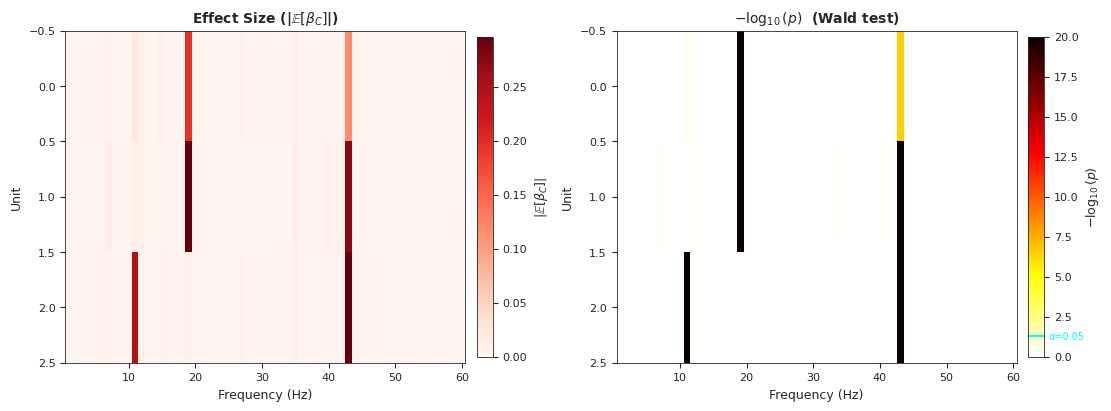

In [6]:
from joint_ssmt.plotting.summary import plot_coupling_summary

fig = plot_coupling_summary(results, effect_type='wald', alpha=0.05, figsize=(11, 4))
plt.show()

### 3b. Significant Coupling Pairs

Read off which (unit, frequency) pairs pass the Wald test.

In [7]:
wald_pval = coupling['wald_pval']   # (S, J)
wald_W    = coupling['wald_W']      # (S, J)
alpha = 0.05

print(f"Significant coupling pairs (alpha = {alpha}):\n")
print(f"  {'Unit':>4}  {'Freq (Hz)':>10}  {'|beta|':>8}  {'Wald W':>8}  {'p-value':>10}")
print("  " + "-" * 50)

for s in range(S):
    for j in range(J):
        if wald_pval[s, j] < alpha:
            print(f"  {s:>4}  {freqs[j]:>10.0f}  {beta_mag[s, j]:>8.4f}  "
                  f"{wald_W[s, j]:>8.2f}  {wald_pval[s, j]:>10.2e}")

Significant coupling pairs (alpha = 0.05):

  Unit   Freq (Hz)    |beta|    Wald W     p-value
  --------------------------------------------------
     0          19    0.1934     80.84    0.00e+00
     0          43    0.1167     29.92    3.19e-07
     1          19    0.3814    244.02    0.00e+00
     1          43    0.2737     98.61    0.00e+00
     2          11    0.2427    111.64    0.00e+00
     2          43    0.3933    107.45    0.00e+00


### 3c. Spectrogram

The inferred spectrogram shows how spectral power evolves over time.
This works on **real data** too (no ground truth needed).
The joint model refines the raw multitaper estimate by leveraging spike information.

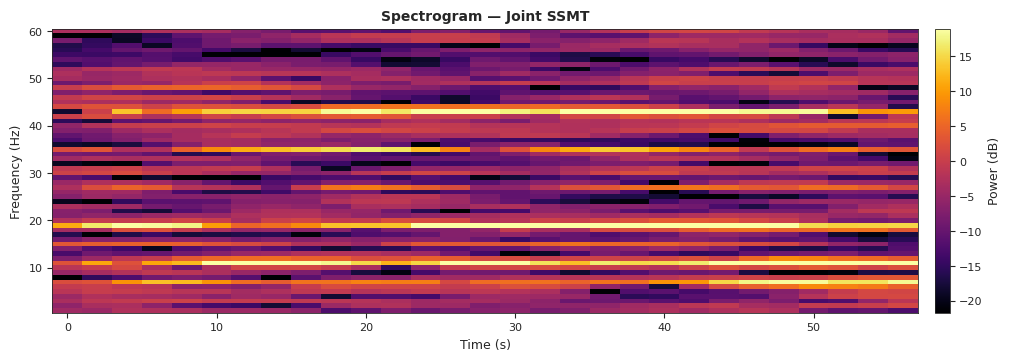

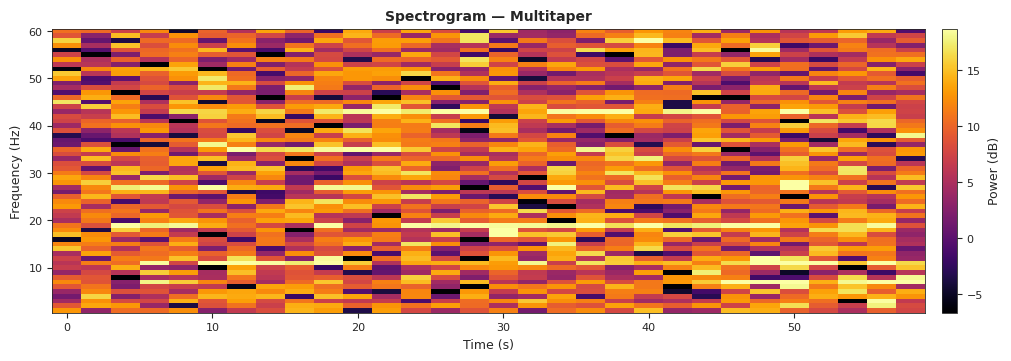

In [8]:
from joint_ssmt.plotting.summary import plot_spectrogram

# Joint model spectrogram (refined by spike information)
fig = plot_spectrogram(results, method='joint', figsize=(10, 3.5))
plt.show()

# Raw multitaper spectrogram (LFP only, for comparison)
fig = plot_spectrogram(results, method='multitaper', figsize=(10, 3.5))
plt.show()

The Joint SSMT model also returns the posterior **variance** at each (frequency, time), so we can put 95% credible bands on the spectral amplitude. Frequencies where spike timing carries information about the LFP tend to have tighter credible bands. 

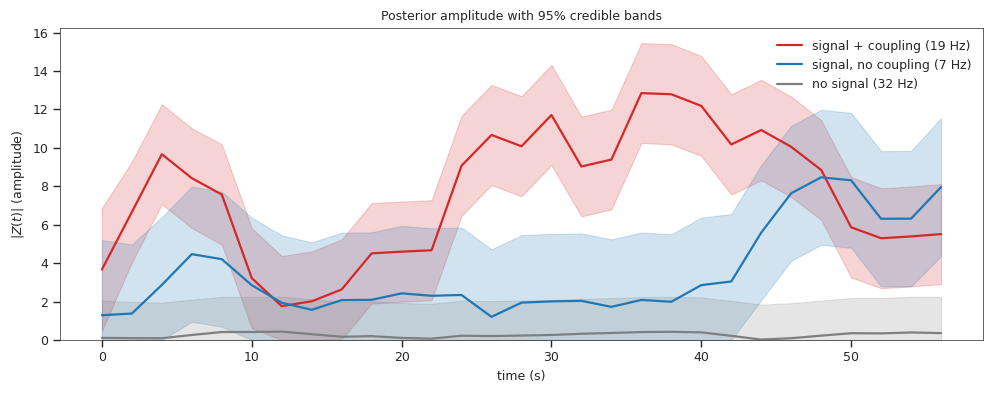

In [ ]:
# Spectral amplitude with 95% credible bands.
# We compare three regimes:
#   1. signal + coupling   (best demonstrates the joint model's benefit)
#   2. signal, no coupling
#   3. no signal
#
# Note that here we picking three frequencies to illustrate how the spike can help reduce the uncertainty in the LFP power. 
# In practice, we can plot the credible bands for all frequencies. 

def pick_demo_freqs_from_results(results, freqs, alpha=0.05):
    """No-ground-truth fallback. Uses the LFP power spectrum and Wald p-values
    from the inference itself.

    - signal + coupling:   frequency with the strongest Wald W (any unit).
    - signal, no coupling: highest LFP-power frequency where no unit's
                           Wald test rejects at level alpha.
    - no signal:           low-power frequency with no significant coupling.
    """
    Z_mean    = np.asarray(results['spectral']['Z_smooth_joint'])
    lfp_power = (np.abs(Z_mean) ** 2).mean(axis=1)
    wald_W    = np.asarray(results['coupling']['wald_W'])      # (S, J)
    wald_p    = np.asarray(results['coupling']['wald_pval'])   # (S, J)

    f_coupled = float(freqs[int(np.argmax(wald_W.max(axis=0)))])

    no_sig_idx = np.where((wald_p > alpha).all(axis=0))[0]
    if len(no_sig_idx) >= 2:
        f_signal_nc = float(freqs[no_sig_idx[int(np.argmax(lfp_power[no_sig_idx]))]])
        low = no_sig_idx[lfp_power[no_sig_idx] < np.median(lfp_power[no_sig_idx])]
        f_no_signal = float(freqs[low[len(low) // 2]]) if len(low) else float(freqs[no_sig_idx[int(np.argmin(lfp_power[no_sig_idx]))]])
    else:
        # Almost everything is significant; just spread three points across the grid
        f_signal_nc = float(freqs[len(freqs) // 4])
        f_no_signal = float(freqs[len(freqs) // 2])
    return f_coupled, f_signal_nc, f_no_signal


# --- pick the three demo frequencies ---------------------------------------
# Simulation: use ground truth. On real data, swap to pick_demo_freqs_from_results.
f_coupled, f_signal_nc, f_no_signal = pick_demo_freqs_from_results(results, freqs)


# --- build the credible-band figure ----------------------------------------
spectral  = results['spectral']
Z_mean    = spectral['Z_smooth_joint']                # (J, K)
Z_var_jmk = spectral['Z_var_joint']                   # (J, M, K)
M         = Z_var_jmk.shape[1]
Z_var     = Z_var_jmk.mean(axis=1) / M                # (J, K), per-component variance of the mean

window_sec = results['metadata']['ctssmt']['window_sec']
t_blocks   = np.arange(Z_mean.shape[1]) * window_sec

panels = [
    (f_coupled,    'signal + coupling',   'tab:red'),
    (f_signal_nc,  'signal, no coupling', 'tab:blue'),
    (f_no_signal,  'no signal',           'tab:gray'),
]

fig, ax = plt.subplots(figsize=(10, 4))
for f_target, label, color in panels:
    j   = int(np.argmin(np.abs(freqs - f_target)))
    f   = freqs[j]
    amp = np.abs(Z_mean[j])
    se  = np.sqrt(Z_var[j] / 2.0)
    lo  = np.maximum(amp - 1.96 * se, 0)
    hi  = amp + 1.96 * se
    ax.plot(t_blocks, amp, lw=1.6, color=color, label=f'{label} ({f:g} Hz)')
    ax.fill_between(t_blocks, lo, hi, alpha=0.2, color=color)
ax.set_ylim(bottom=0)
ax.set_xlabel('time (s)')
ax.set_ylabel(r'$|Z(t)|$ (amplitude)')
ax.set_title('Posterior amplitude with 95% credible bands')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

### 3d.Metadata

The `metadata.json` file records the configs and timing for reproducibility.

In [26]:
meta = results['metadata']
print(f"Elapsed time:      {meta['timing']['elapsed_seconds']:.1f} s")
print(f"MCMC samples:      {meta['mcmc']['n_samples']}")
print(f"Significant bands: {meta['detection']['n_significant_bands']}")
print(f"Frequency grid:    {meta['ctssmt']['n_freqs']} bands")

Elapsed time:      71.6 s
MCMC samples:      250
Significant bands: 3
Frequency grid:    60 bands


---
## 4. Additional Plots

The plots below are useful for additional analysis and intepretation of the results.

### 4a. Beta Posterior Scatter

Visualize the full posterior distribution of $\beta = \beta_R + i\beta_I$ for each frequency.
Coupled bands show a concentrated posterior away from the origin.

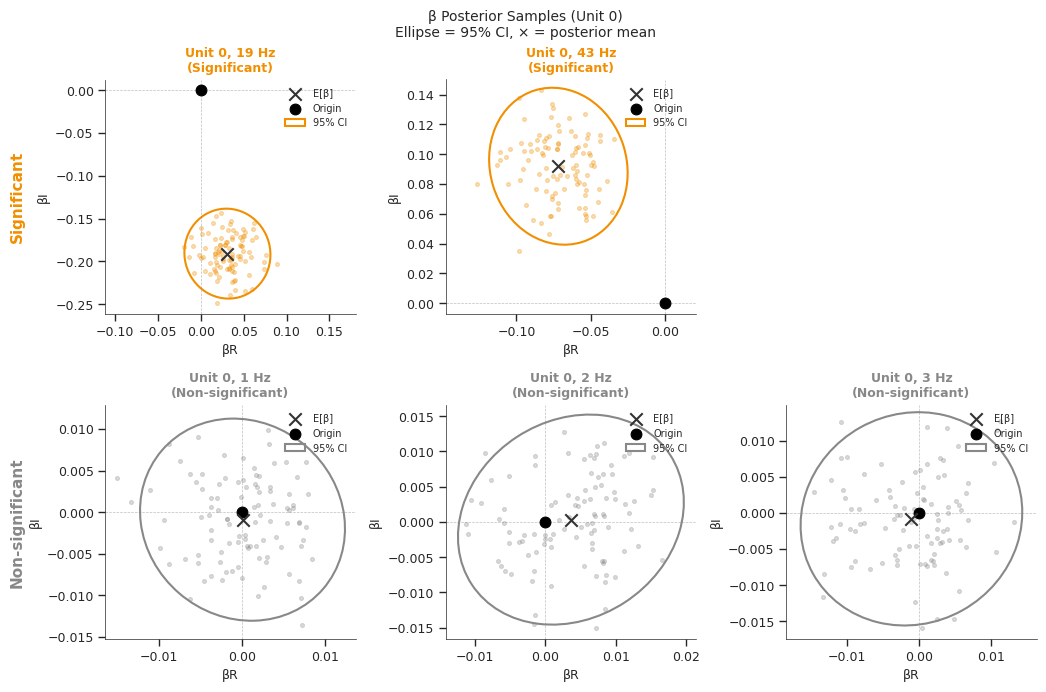

In [18]:
from joint_ssmt.plotting.beta_posterior import plot_beta_posterior_scatter

fig = plot_beta_posterior_scatter(
    coupling['beta_trace'],
    freqs,
    None,  # pass a file path to save, or None = display only
    unit_idx=0,
    burn_in_frac=0.6,
)
plt.show()

### 4b. Phase distribution


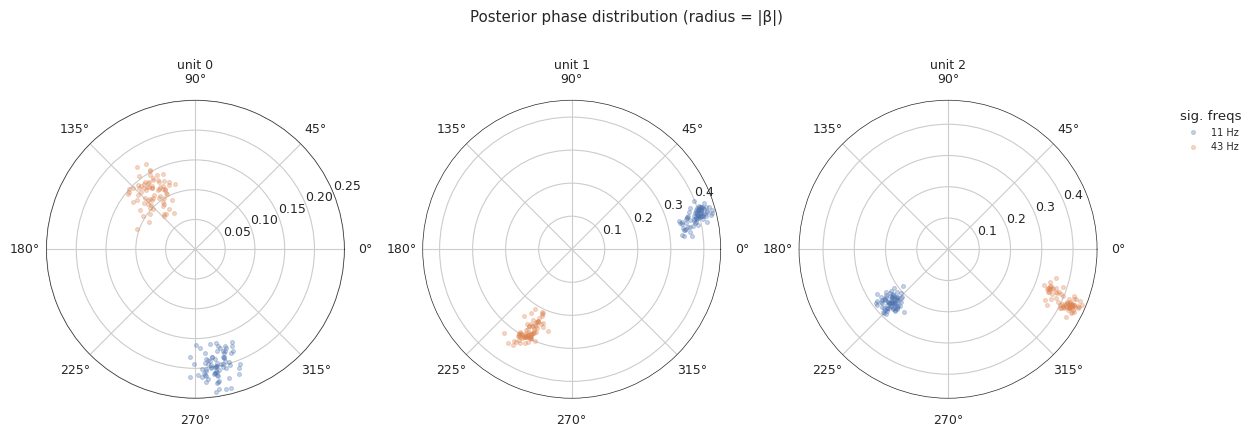

In [29]:
# Polar view of the posterior phase distribution at significant frequencies.
beta_trace = coupling['beta_trace']
J_grid = len(freqs)
burn = int(0.7 * beta_trace.shape[0])
bR = beta_trace[burn:, :, 1:1+J_grid]
bI = beta_trace[burn:, :, 1+J_grid:1+2*J_grid]
phase_samples = np.arctan2(bI, bR)
mag_samples = np.sqrt(bR**2 + bI**2)

rng = np.random.default_rng(0)
n_show = min(400, phase_samples.shape[0])
idx = rng.choice(phase_samples.shape[0], n_show, replace=False)

fig, axes = plt.subplots(1, S, figsize=(4.2 * S, 4.2),
                         subplot_kw={'projection': 'polar'})
if S == 1:
    axes = [axes]

for s in range(S):
    ax = axes[s]
    sig = wald_pval[s] < 0.05
    for j in np.where(sig)[0]:
        ax.scatter(phase_samples[idx, s, j], mag_samples[idx, s, j],
                   alpha=0.3, s=8, label=f'{freqs[j]:.0f} Hz')
    ax.set_title(f'unit {s}', y=1.08)
    if s == S - 1 and sig.any():
        ax.legend(bbox_to_anchor=(1.25, 1), fontsize=7, loc='upper left',
                  title='sig. freqs')

plt.suptitle('Posterior phase distribution (radius = |β|)', y=1.02)
plt.tight_layout()
plt.show()


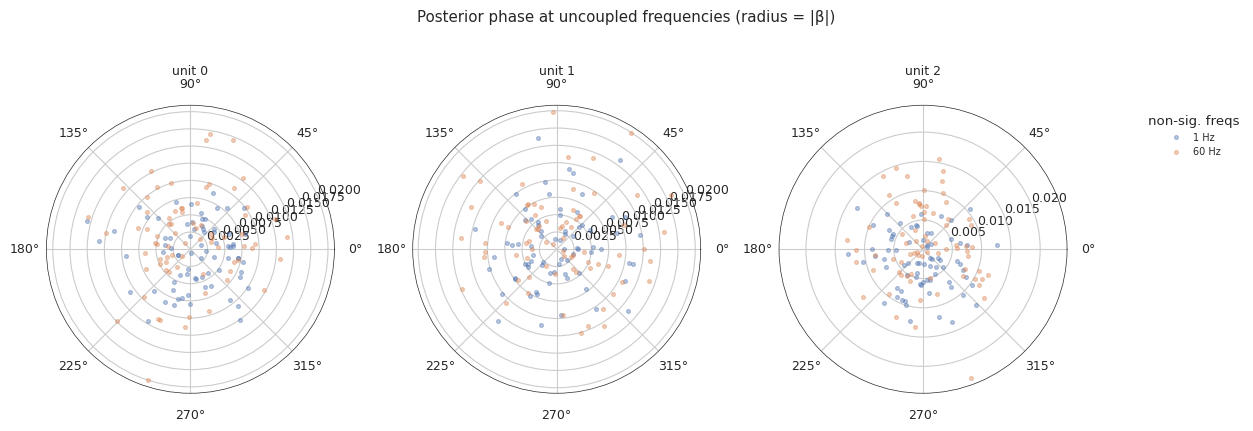

In [33]:
# Polar view at NON-significant (uncoupled) frequencies, for contrast.
n_uncoupled_show = 2   

fig, axes = plt.subplots(1, S, figsize=(4.2 * S, 4.2),
                         subplot_kw={'projection': 'polar'})
if S == 1:
    axes = [axes]

for s in range(S):
    ax = axes[s]
    nonsig_idx = np.where(wald_pval[s] >= 0.05)[0]
    if len(nonsig_idx) > n_uncoupled_show:
        pick = np.linspace(0, len(nonsig_idx) - 1, n_uncoupled_show, dtype=int)
        chosen = nonsig_idx[pick]
    else:
        chosen = nonsig_idx
    for j in chosen:
        ax.scatter(phase_samples[idx, s, j], mag_samples[idx, s, j],
                   alpha=0.4, s=8, label=f'{freqs[j]:.0f} Hz')
    ax.set_title(f'unit {s}', y=1.08)
    if s == S - 1 and len(chosen) > 0:
        ax.legend(bbox_to_anchor=(1.25, 1), fontsize=7, loc='upper left',
                  title='non-sig. freqs')

plt.suptitle('Posterior phase at uncoupled frequencies (radius = |β|)', y=1.02)
plt.tight_layout()
plt.show()